In [5]:
import lmdb
import pickle
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


[INFO] 총 샘플 수: 12634
[ficoords (raw)]
[[9.190e+02 1.821e+03 1.000e+00 0.000e+00 0.000e+00]
 [9.160e+02 1.818e+03 1.000e+00 0.000e+00 0.000e+00]
 [8.960e+02 1.918e+03 1.000e+00 0.000e+00 0.000e+00]
 [8.960e+02 1.935e+03 1.000e+00 0.000e+00 0.000e+00]
 [9.060e+02 1.950e+03 1.000e+00 0.000e+00 0.000e+00]
 [9.140e+02 1.950e+03 1.000e+00 0.000e+00 0.000e+00]
 [9.240e+02 1.946e+03 1.000e+00 0.000e+00 0.000e+00]
 [9.440e+02 1.920e+03 1.000e+00 0.000e+00 0.000e+00]
 [9.440e+02 1.903e+03 1.000e+00 0.000e+00 0.000e+00]
 [9.290e+02 1.890e+03 1.000e+00 0.000e+00 0.000e+00]
 [9.050e+02 1.893e+03 1.000e+00 0.000e+00 0.000e+00]
 [8.840e+02 1.900e+03 0.000e+00 1.000e+00 0.000e+00]]


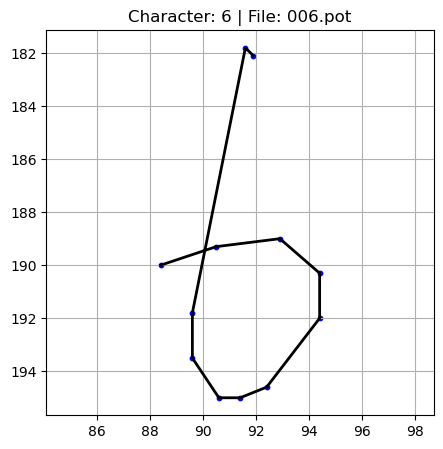

In [8]:
def load_lmdb_sample(lmdb_dir, sample_index=0):
    env = lmdb.open(lmdb_dir, readonly=True, lock=False, readahead=False, meminit=False)
    with env.begin(write=False) as txn:
        num_sample = int(txn.get('num_sample'.encode('utf-8')).decode())
        print(f"[INFO] 총 샘플 수: {num_sample}")

        if sample_index >= num_sample:
            raise IndexError(f"샘플 인덱스 {sample_index}는 범위를 벗어남 (총 {num_sample}개)")

        data = pickle.loads(txn.get(str(sample_index).encode('utf-8')))
        return data

def visualize_absolute_coords(coords, label="?", fname=""):
    coords = coords.astype(np.float32)
    coords[:, 0] /= 10
    coords[:, 1] /= 10

    x, y = coords[:, 0], coords[:, 1]

    plt.figure(figsize=(5, 5))
    plt.plot(x, y, 'k-', linewidth=2)
    plt.scatter(x, y, c='blue', s=10)
    plt.gca().invert_yaxis()
    plt.title(f"Character: {label} | File: {fname}")
    plt.axis("equal")
    plt.grid(True)
    plt.show()


lmdb_path = "../../../exp-sdt_en/data_eng/CASIA_ENGLISH/test"
sample_idx = 40

sample = load_lmdb_sample(lmdb_path, sample_idx)
coords = sample['coordinates']
tag_char = sample.get('tag_char', '?')
fname = sample.get('fname', 'unknown')

print("[ficoords (raw)]")
print(coords[:])

visualize_absolute_coords(coords, label=tag_char, fname=fname)


[INFO] samples scanned: 5000 / total=12634
[INFO] unique lengths (first 20): [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23] (… total 32)
[INFO] top-10 length counts: [(14, 506), (15, 464), (16, 451), (13, 409), (12, 382), (17, 377), (18, 321), (11, 299), (10, 261), (19, 237)]
[INFO] detected columns: {'x': 0, 'y': 1, 'pm': 2, 'eos': 4, 'eoc': 3}
[INFO] pm: ones=68789 / total=76055 (ratio=0.9045)
[INFO] eos: ones=0 / total=76055 (ratio=0.0000)
[INFO] eoc: ones=7266 / total=76055 (ratio=0.0955)
[INFO] equal-arc-length score (lower is more uniform): mean=0.0088, std=0.0051, p25=0.0053, p50=0.0072, p75=0.0105
[INFO] coord max stats: mean=61401.62, p90=101078.30, max=253450.00


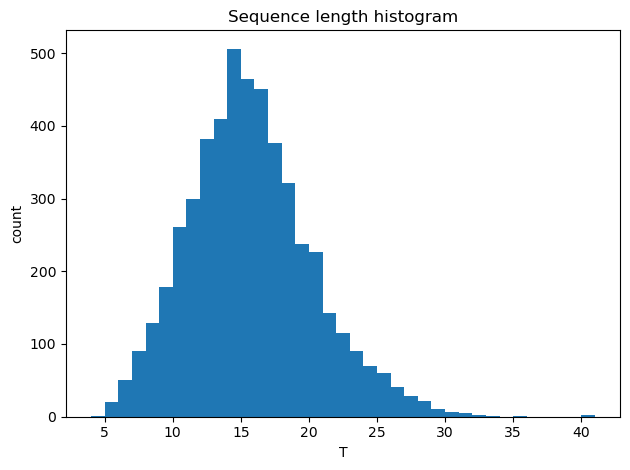

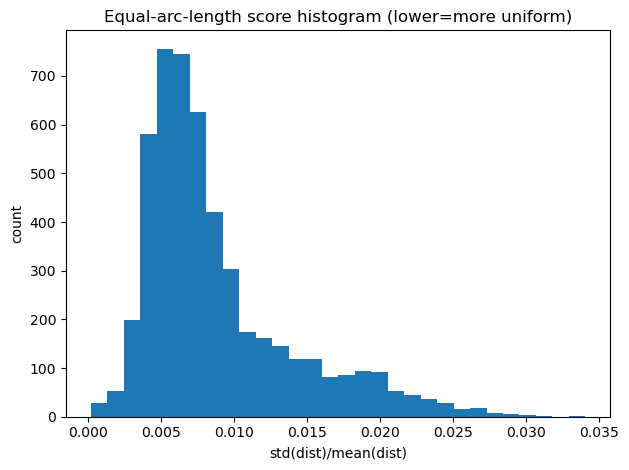

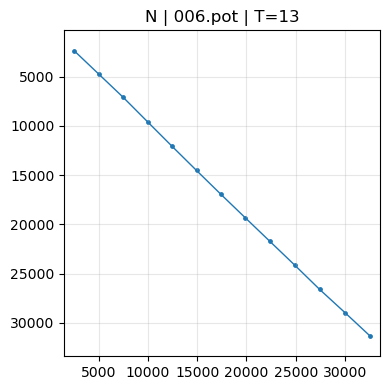

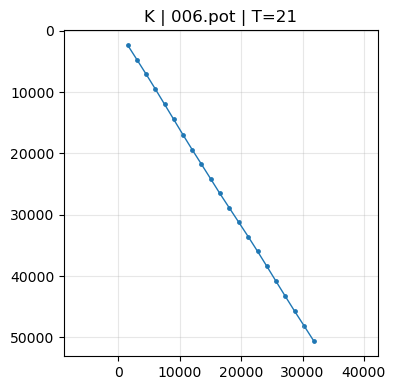

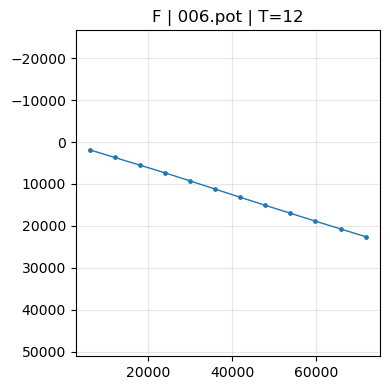

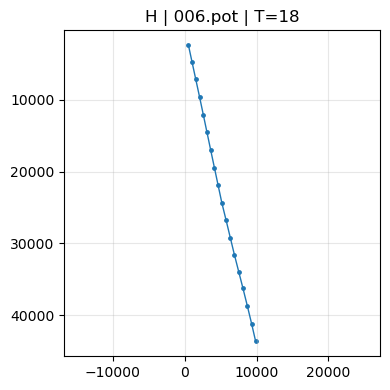

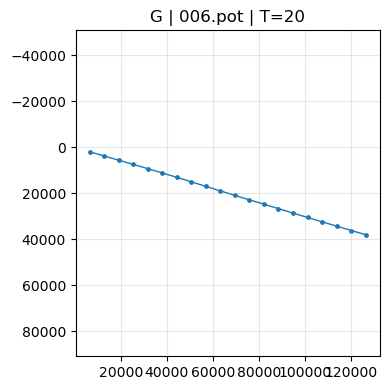

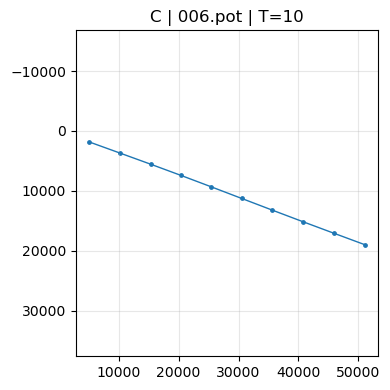

In [9]:
import lmdb, pickle, numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

def load_lmdb_sample(lmdb_dir, sample_index=0):
    env = lmdb.open(lmdb_dir, readonly=True, lock=False, readahead=False, meminit=False)
    with env.begin(write=False) as txn:
        num_sample = int(txn.get(b'num_sample').decode())
        if sample_index >= num_sample:
            raise IndexError(f"index {sample_index} out of {num_sample}")
        data = pickle.loads(txn.get(str(sample_index).encode('utf-8')))
        return data, num_sample

def detect_cols(coords):
    T, K = coords.shape

    x_idx, y_idx = 0, 1
    cand = list(range(K))
    cand.remove(x_idx); cand.remove(y_idx)

    binlike = []
    for j in cand:
        v = coords[:, j]
        uniq = np.unique(v)
        if set(uniq.tolist()) <= {0,1}:
            binlike.append(j)


    pm_idx, eos_idx, eoc_idx = None, None, None
    if len(binlike) >= 3:

        tail = [j for j in binlike if coords[-1, j] == 1]
        if len(tail) >= 1:
            eoc_idx = tail[0]
            binlike.remove(eoc_idx)


        counts = [(j, int(coords[:, j].sum())) for j in binlike]
        counts.sort(key=lambda x: abs(x[1]-T/10))
        if counts:
            eos_idx = counts[0][0]
            binlike.remove(eos_idx)
        if binlike:
            pm_idx = binlike[0]
    elif len(binlike) == 2:


        tail = [j for j in binlike if coords[-1, j] == 1]
        if tail:
            eoc_idx = tail[0]
            binlike.remove(eoc_idx)
        if binlike:
            eos_idx = binlike[0]
    elif len(binlike) == 1:

        eos_idx = binlike[0]

    return dict(x=x_idx, y=y_idx, pm=pm_idx, eos=eos_idx, eoc=eoc_idx)

def to_abs(coords, col):
    xy = coords[:, [col['x'], col['y']]].astype(np.float32)
    if xy.shape[0] <= 1:
        return xy
    mean_step = np.mean(np.abs(xy[1:] - xy[:-1]))
    mean_level = np.mean(np.abs(xy))
    if mean_step < 0.1 * max(mean_level, 1e-3):

        xy = np.cumsum(xy, axis=0)
    return xy

def stroke_splits(coords, col):
    eos = coords[:, col['eos']] if col.get('eos') is not None else np.zeros(coords.shape[0])
    idx = np.where(eos == 1)[0].tolist()

    splits = []
    s = 0
    for e in idx:
        splits.append((s, e))
        s = e+1
    if s < coords.shape[0]:
        splits.append((s, coords.shape[0]-1))
    return splits

def equal_arclen_score(xy):
    if xy.shape[0] <= 2:
        return np.nan
    d = np.sqrt(((xy[1:] - xy[:-1])**2).sum(axis=1))
    m = max(d.mean(), 1e-6)
    return d.std() / m

def scan_lmdb(lmdb_dir, max_n=10000, sample_plot=6, show=True):
    env = lmdb.open(lmdb_dir, readonly=True, lock=False, readahead=False, meminit=False)
    lengths = []
    eq_scores = []
    eq_scores_stroke = []
    bin_stats = Counter()
    scale_hint_vals = []
    col_examples = None

    samples_to_plot = []
    with env.begin(write=False) as txn:
        num = int(txn.get(b'num_sample').decode())
        n = min(num, max_n)
        for i in range(n):
            rec = pickle.loads(txn.get(str(i).encode('utf-8')))
            coords = np.array(rec['coordinates'])
            label = rec.get('tag_char', '?')
            fname  = rec.get('fname', f'#{i}')

            col = detect_cols(coords)
            if col_examples is None:
                col_examples = col


            xy_abs = to_abs(coords, col)

            scale_hint_vals.append(xy_abs.max())

            T = xy_abs.shape[0]
            lengths.append(T)


            eq_scores.append(equal_arclen_score(xy_abs))


            if col.get('eos') is not None:
                splits = stroke_splits(coords, col)
                per = []
                for s, e in splits:
                    if e - s + 1 >= 3:
                        per.append(equal_arclen_score(xy_abs[s:e+1]))
                if per:
                    eq_scores_stroke.append(np.nanmean(per))


            for k in ['pm','eos','eoc']:
                j = col.get(k)
                if j is not None:
                    ones = int(coords[:, j].sum())
                    bin_stats[(k,'ones')] += ones
                    bin_stats[(k,'total')] += T


            if len(samples_to_plot) < sample_plot:
                samples_to_plot.append((xy_abs.copy(), label, fname))


    unique_lengths = sorted(set(lengths))
    print(f"[INFO] samples scanned: {len(lengths)} / total={num}")
    print(f"[INFO] unique lengths (first 20): {unique_lengths[:20]} (… total {len(unique_lengths)})")
    cnt = Counter(lengths)
    most_common = cnt.most_common(10)
    print("[INFO] top-10 length counts:", most_common)

    if col_examples:
        print("[INFO] detected columns:", col_examples)

    for k in ['pm','eos','eoc']:
        ones = bin_stats.get((k,'ones'),0)
        tot  = bin_stats.get((k,'total'),0)
        if tot>0:
            print(f"[INFO] {k}: ones={ones} / total={tot} (ratio={ones/max(tot,1):.4f})")


    eq_arr = np.array([x for x in eq_scores if not np.isnan(x)])
    if eq_arr.size:
        print(f"[INFO] equal-arc-length score (lower is more uniform): "
              f"mean={eq_arr.mean():.4f}, std={eq_arr.std():.4f}, "
              f"p25={np.percentile(eq_arr,25):.4f}, p50={np.percentile(eq_arr,50):.4f}, p75={np.percentile(eq_arr,75):.4f}")


    sv = np.array(scale_hint_vals)
    print(f"[INFO] coord max stats: mean={sv.mean():.2f}, p90={np.percentile(sv,90):.2f}, max={sv.max():.2f}")


    if show:

        plt.figure()
        plt.hist(lengths, bins=range(min(lengths), max(lengths)+2))
        plt.title("Sequence length histogram")
        plt.xlabel("T"); plt.ylabel("count")
        plt.tight_layout()


        if eq_arr.size:
            plt.figure()
            plt.hist(eq_arr, bins=30)
            plt.title("Equal-arc-length score histogram (lower=more uniform)")
            plt.xlabel("std(dist)/mean(dist)"); plt.ylabel("count")
            plt.tight_layout()


        for xy,label,fname in samples_to_plot:
            plt.figure(figsize=(4,4))
            plt.plot(xy[:,0], xy[:,1], '-', linewidth=1)
            plt.scatter(xy[:,0], xy[:,1], s=6)
            plt.gca().invert_yaxis()
            plt.axis('equal'); plt.grid(True, alpha=0.3)
            plt.title(f"{label} | {fname} | T={xy.shape[0]}")
            plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    lmdb_path = "../../../exp-sdt_en/data_eng/CASIA_ENGLISH/test"
    scan_lmdb(lmdb_path, max_n=5000, sample_plot=6, show=True)


문자 라벨: J
이미지 shape: (64, 64)


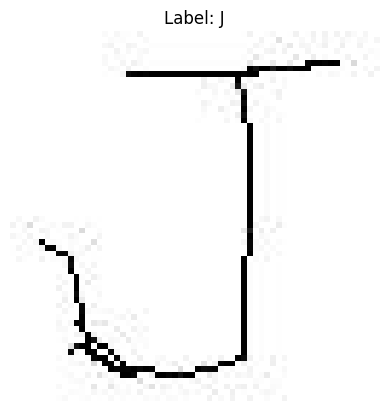

In [10]:
pkl_path = "../../data/eng/CASIA_ENGLISH/test_style_samples/006.pkl"


with open(pkl_path, "rb") as f:
    sample_list = pickle.load(f)


sample = sample_list[0]


print(f"문자 라벨: {sample['label']}")
print(f"이미지 shape: {sample['img'].shape}")


plt.imshow(sample['img'], cmap='gray')
plt.title(f"Label: {sample['label']}")
plt.axis('off')
plt.show()
